### EKİP ÜYELERİ
- Sinem Özdemir - 2022123026
- Yasin Yıldız - 2022123058
- Bekir Aydoğan - 2022123043
- Atillacan Doğan - 2022123041

#### Kullandığımız veri seti "Big Mart Sales Prediction" veri seti, perakende satışlarını tahmin etmek için kullanılan popüler bir veri setidir.
- https://www.kaggle.com/datasets/shivan118/big-mart-sales-prediction-datasets?resource=*download*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/drive/MyDrive/bigmart/train.csv')
#veriyi direkt drive üzerinden çekiyoruz.

In [3]:
df.info()
#veri seti hakkında bilgi sahibi olmak için info() methodunu kullanıyoruz.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


Ürünle İlgili Sütunlar
- Item_Identifier: Her bir ürün için tanımlanmış benzersiz ürün kimlik numarası (ID).

- Item_Weight: Ürünün ağırlığı.

- Item_Fat_Content: Ürünün yağ içeriği (Örn: Düşük Yağlı 'Low Fat' veya Normal 'Regular'). Not: Veri setinde genelde 'LF', 'low fat' gibi aynı anlama gelen farklı yazımlar bulunur, bunların temizlenmesi gerekir.

- Item_Visibility: Bir mağazadaki tüm ürünlerin toplam teşhir alanı içinde, o ürüne ayrılan alanın yüzdesi.

- Item_Type: Ürünün ait olduğu kategori (Örn: Mandıra, Yumuşak İçecekler, Et, Meyve-Sebze vb.).

- Item_MRP: Ürünün Maksimum Perakende Satış Fiyatı (Liste fiyatı).

Mağaza (Outlet) ile İlgili Sütunlar
- Outlet_Identifier: Her bir mağaza için tanımlanmış benzersiz mağaza kimlik numarası (ID).

- Outlet_Establishment_Year: Mağazanın kurulduğu yıl.

- Outlet_Size: Mağazanın alanı bakımından büyüklüğü (Small, Medium, High - Küçük, Orta, Büyük).

- Outlet_Location_Type: Mağazanın bulunduğu şehrin tipi (Tier 1, Tier 2, Tier 3 gibi gelişmişlik seviyeleri).

- Outlet_Type: Mağazanın tipi (Örn: Bakkal 'Grocery Store' veya Süpermarket 'Supermarket Type1, Type2, Type3').

Hedef Değişken (Tahmin Edilecek Sütun)
- Item_Outlet_Sales: Belirli bir üründen belirli bir mağazada yapılan toplam satış miktarı. (Makine öğrenmesi modellerinde tahmin edilmeye çalışılan değer budur.)

In [4]:
df.describe()
#columnlar hakkında sayısal değerleri almak için describe() methodunu kullanıyoruz.

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [5]:
for col in df.columns:
  print(col,df[col].unique())
#tüm columnlardaki eşsiz yani unique değerleri bularak yanlış veya nan değerleri belirliyoruz.

Item_Identifier ['FDA15' 'DRC01' 'FDN15' ... 'NCF55' 'NCW30' 'NCW05']
Item_Weight [ 9.3    5.92  17.5   19.2    8.93  10.395 13.65     nan 16.2   11.8
 18.5   15.1   17.6   16.35   9.    13.35  18.85  14.6   13.85  13.
  7.645 11.65   5.925 19.25  18.6   18.7   17.85  10.     8.85   9.8
 13.6   21.35  12.15   6.42  19.6   15.85   7.39  10.195  9.895 10.895
  7.905  9.195  8.365  7.97  17.7   19.35   8.645 15.6   18.25   7.855
  7.825  8.39  12.85  19.     5.905  7.76  16.75  15.5    6.055  6.305
 20.85  20.75   8.895 19.7    8.75  13.3    8.31  19.75  17.1   10.5
  6.635 14.15   8.89   9.1    7.5   16.85   7.485 11.6   12.65  20.25
  8.6   12.6    8.88  20.5   13.5    7.235  6.92   8.02  12.8   16.6
 14.    16.    21.25   7.365 18.35   5.465  7.27   6.155 19.5   15.2
 14.5   13.1   12.3   11.1   11.3    5.75  11.35   6.525 10.3    5.78
 11.85  18.75   5.26  16.1    9.5   13.8   14.65   6.67   6.11  17.2
  6.32   4.88   5.425 14.1    7.55  17.25  12.    10.1    7.785 13.15
  8.5    7.63

In [6]:
#'Item_Fat_Content' sütunundaki 'LF' ve 'low fat' değerlerini 'Low Fat' olarak tek bir standartta birleştirelim.
#Regular ve reg değerlerini de birleştirdik.

print('Değişimden önce Item_Fat_Content benzersiz değerleri:')
display(df['Item_Fat_Content'].unique())

df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

print('\nDeğişimden sonra Item_Fat_Content benzersiz değerleri:')
display(df['Item_Fat_Content'].unique())

Değişimden önce Item_Fat_Content benzersiz değerleri:


array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)


Değişimden sonra Item_Fat_Content benzersiz değerleri:


array(['Low Fat', 'Regular'], dtype=object)

In [7]:
print('Eksik değerler doldurulmadan önce:')
display(df.isnull().sum())
#isnull().sum() methodları ile veri setindeki null değerleri buluyoruz.

# Item_Weight sütunundaki eksik değerleri ortalama ile doldur
item_weight_mean = df['Item_Weight'].mean()
df['Item_Weight'].fillna(item_weight_mean, inplace=True)

# Outlet_Size sütunundaki eksik değerleri mod (en sık tekrar eden değer) ile doldur
# mode() birden fazla mod değeri dönebilir, bu yüzden ilkini alıyoruz.
outlet_size_mode = df['Outlet_Size'].mode()[0]
df['Outlet_Size'].fillna(outlet_size_mode, inplace=True)

print('\nEksik değerler doldurulduktan sonra:')
display(df.isnull().sum())

Eksik değerler doldurulmadan önce:


,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0



Eksik değerler doldurulduktan sonra:


/tmp/ipykernel_435/1489605234.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(item_weight_mean, inplace=True)
/tmp/ipykernel_435/1489605234.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0



- Item_Outlet_Sales sütunundaki aykırı değerleri görsel olarak tespit etmek için bir kutu grafiği (boxplot) veya histogram oluşturalım.


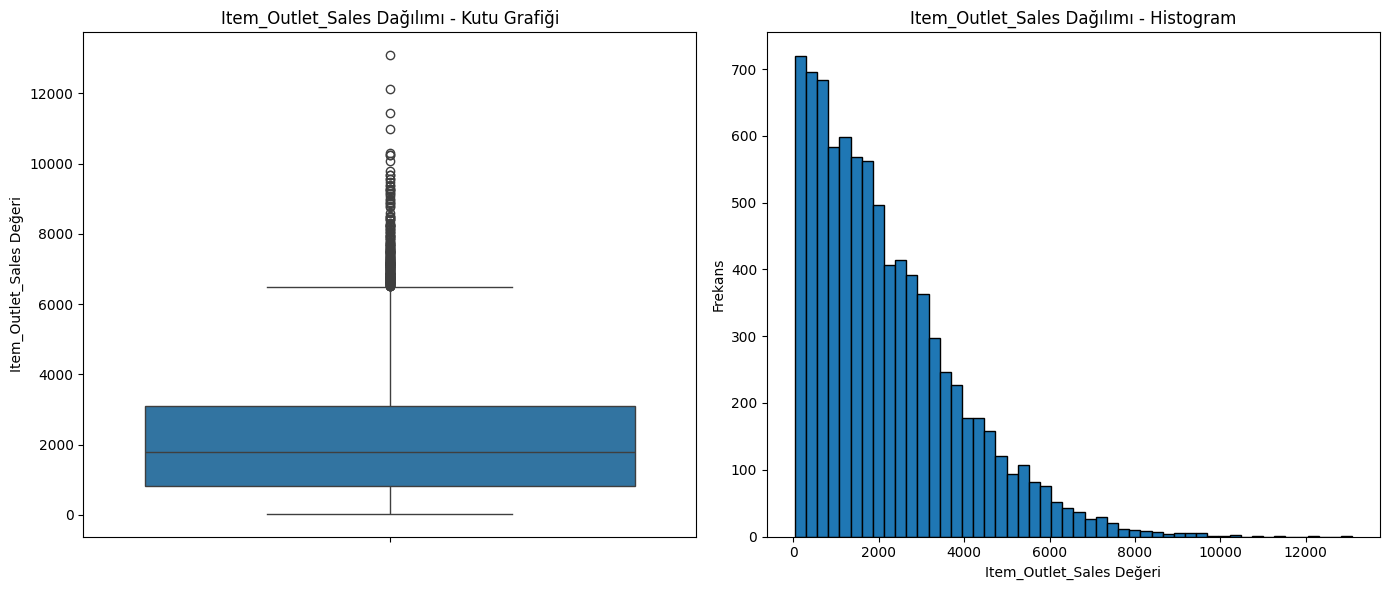

In [8]:
#başta import ettiğimiz matplotlib ve seaborn kütüphanelerini burada görselleştirme amaçlı kullanıyoruz.
plt.figure(figsize=(14, 6))

# Kutu Grafiği (Boxplot)
plt.subplot(1, 2, 1) # 1 satır, 2 sütun, 1. grafik
sns.boxplot(y=df['Item_Outlet_Sales'])
plt.title('Item_Outlet_Sales Dağılımı - Kutu Grafiği')
plt.ylabel('Item_Outlet_Sales Değeri')

# Histogram
plt.subplot(1, 2, 2) # 1 satır, 2 sütun, 2. grafik
plt.hist(df['Item_Outlet_Sales'], bins=50, edgecolor='black')
plt.title('Item_Outlet_Sales Dağılımı - Histogram')
plt.xlabel('Item_Outlet_Sales Değeri')
plt.ylabel('Frekans')

plt.tight_layout()
plt.show()

### Aykırı Değer Analizi ve Etkileri

Yukarıdaki kutu grafiği ve histogram, 'Item_Outlet_Sales' sütunundaki aykırı değerleri açıkça göstermektedir.

**Gözlemler:**

1.  **Kutu Grafiği (Boxplot):** Kutu grafiği, medyan, çeyrekler arası aralık (IQR) ve potansiyel aykırı değerleri gösterir. Grafik, ortalama satış değerinin üzerinde **çok sayıda aykırı değer** olduğunu açıkça işaret etmektedir. Bu aykırı değerler, çoğu satışın yoğunlaştığı aralığın oldukça dışındadır.

2.  **Histogram:** Histogram, satış dağılımının sağa çarpık olduğunu göstermektedir. Çoğu satışın düşük ve orta aralıkta toplandığı, ancak çok daha yüksek satış değerlerine sahip az sayıda gözlem olduğu görülmektedir. Bu uzun sağ kuyruk, kutu grafiğindeki aykırı değerlerin varlığını desteklemektedir.

**Aykırı Değerlerin Özellikleri:**

*   **Yüksek Satış Değerleri:** Aykırı değerler, genellikle 7000 birimin üzerindeki satış değerleridir ve bazıları 13000 birimine kadar çıkmaktadır.
*   **Seyrek Görülme:** Bu yüksek satış değerleri, genel veri setine kıyasla oldukça nadir görülmektedir. Histogramdaki uzun, ince kuyruk bu durumu doğrular.

**MLP Modeli Üzerindeki Potansiyel Etkisi:**

Çok Katmanlı Algılayıcı (MLP) gibi regresyon modelleri, aykırı değerlere karşı hassas olabilir. Bu aykırı değerlerin MLP modeli üzerindeki olası etkileri şunlardır:

*   **Modelin Sapması (Bias):** Aşırı yüksek aykırı değerler, modelin öğrenme sürecini bozarak tahminleri gerçek ortalamadan uzaklaştırabilir. Model, bu nadir ve yüksek değerleri "genel" bir trend olarak yorumlamaya çalışabilir, bu da normal satış değerleri için kötü tahminlere yol açar.
*   **Yüksek Varyans:** Modelin eğitim verilerine aşırı uyum sağlamasına (overfitting) neden olabilir. Aykırı değerleri açıklamaya çalışırken, model veri setindeki gürültüyü de öğrenerek genelleme yeteneğini kaybedebilir.
*   **Daha Uzun Eğitim Süresi:** Aykırı değerler, gradyan inişi gibi optimizasyon algoritmalarının yakınsama süresini uzatabilir veya yakınsamayı zorlaştırabilir.
*   **Metriklerin Çarpıtılması:** MSE (Ortalama Kare Hata) veya RMSE (Ortalama Kare Kök Hata) gibi hata metrikleri, aykırı değerlerin karesel hataya olan büyük katkısı nedeniyle şişebilir ve modelin performansını yanlış yansıtabilir.

**Aykırı Değerleri Ele Alma Stratejileri:**

Bu aykırı değerleri yönetmek için birkaç strateji düşünülebilir:

1.  **Dönüşüm (Transformation):** `Item_Outlet_Sales` sütununa logaritmik (örneğin, `np.log1p`) veya karekök dönüşümü uygulamak, verinin çarpıklığını azaltarak ve aykırı değerlerin etkisini yumuşatarak dağılımı normale daha yakın hale getirebilir. Bu, modelin daha iyi öğrenmesine yardımcı olabilir.
2.  **Ayırma (Capping/Winsorization):** Aykırı değerleri, belirli bir üst eşik değerine (örneğin, 99. persentil) sabitlemek. Bu yöntem, aykırı değerlerin varlığını korurken aşırı uç değerlerin etkisini sınırlar. Bu genellikle IQR kuralı ile belirlenen üst sınırın dışındaki değerleri belirli bir noktaya çekmek şeklinde yapılır.
3.  **Kaldırma (Removal):** Eğer aykırı değerler veri toplama hatasından kaynaklanıyorsa veya çok nadir ve anormal durumları temsil ediyorsa, veri setinden kaldırılabilir. Ancak bu, bilgi kaybına yol açabilir ve dikkatli yapılmalıdır.
4.  **Robüst Modeller Kullanma:** MLP modeli yerine, aykırı değerlere daha az duyarlı olan ağaç tabanlı modeller (örneğin, Random Forest, Gradient Boosting) veya robüst regresyon modelleri tercih edilebilir.

**Sonuç ve Önerilen Adım:**

'Item_Outlet_Sales' sütununda belirgin bir şekilde sağa çarpık bir dağılım ve çok sayıda yüksek değerli aykırı değer bulunmaktadır. MLP gibi modellerin performansını olumsuz etkileyebilecek bu durum için, veri dönüşümü (logaritmik dönüşüm) veya ayırma (capping) gibi yöntemlerin uygulanması, modelin daha iyi genelleme yapmasına ve daha doğru tahminler üretmesine yardımcı olacaktır. Veri dönüşümü genellikle daha az bilgi kaybına neden olduğu için iyi bir başlangıç noktası olabilir.

## Aykırı Değerleri Tespit Etme

Görselleştirmelerden veya istatistiksel yöntemlerden (örneğin IQR metodu) faydalanarak Item_Outlet_Sales sütunundaki aşırı yüksek satışa sahip aykırı değerleri belirleyin.


In [9]:
Q1 = df['Item_Outlet_Sales'].quantile(0.25) # Verinin en küçük %25'lik kısmının bittiği değer.
Q3 = df['Item_Outlet_Sales'].quantile(0.75) # Verinin %75'lik kısmının bittiği (en büyük %25'in başladığı) değer.
IQR = Q3 - Q1                               # Çeyrekler açıklığı: Verinin merkezindeki %50'lik dilimin genişliği.

# Üst sınır formülü: Q3 değerinin IQR'ın 1.5 katı kadar üzerine çıkmasıyla bulunur.
# Bu sınırın üzerindeki her değer "istatistiksel olarak aşırı yüksek" kabul ederiz.
upper_bound = Q3 + 1.5 * IQR

# Satış rakamı, hesapladığımız üst sınırdan (upper_bound) büyük olan satırları buluyoruz.
outliers = df[df['Item_Outlet_Sales'] > upper_bound]

print(f"Q1 (First Quartile): {Q1:.2f}")
print(f"Q3 (Third Quartile): {Q3:.2f}")
print(f"IQR (Interquartile Range): {IQR:.2f}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")

print(f"\nNumber of outliers detected: {len(outliers)}") # Kaç tane aşırı yüksek satış kaydı var ona bakıyoruz.
print("\nDescriptive statistics for Item_Outlet_Sales outliers:")
display(outliers['Item_Outlet_Sales'].describe())        # Bu aykırı değerlerin ortalaması, min ve max değerleri neler diye bakıyoruz.

Q1 (First Quartile): 834.25
Q3 (Third Quartile): 3101.30
IQR (Interquartile Range): 2267.05
Upper Bound for Outliers: 6501.87

Number of outliers detected: 186

Descriptive statistics for Item_Outlet_Sales outliers:


,Item_Outlet_Sales
count,186.000000
mean,7646.329986
std,1113.245443
min,6503.534400
25%,6853.079400
50%,7256.887100
75%,8101.953750
max,13086.964800


## Aykırı Değerleri İnceleme

Tespit edilen aykırı değerlerin detaylı özelliklerini (ürün adı, ağırlığı, satış fiyatı vb.) inceleyerek bu durumun nedenlerini anlamaya çalışın.


- Bu kod, az önce hesapladığın üst sınırı (upper_bound) aşan ve "aykırı" olarak damgalanan verilerin bizzat kendisini kanlı canlı görmeni sağlar. Veri setinin tamamına bakmak yerine, sadece "problemli" veya "ekstrem" olan kısımları mikroskop altına yatırmak gibidir.

In [10]:
print("İlk 5 aykırı değer gözlemi:")
display(outliers.head())

İlk 5 aykırı değer gözlemi:


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
43,FDC02,21.350000,Low Fat,0.069103,Canned,259.9278,OUT018,2009,Medium,Tier 3,Supermarket Type2,6768.5228
130,FDY25,12.857645,Low Fat,0.033810,Canned,180.5976,OUT027,1985,Medium,Tier 3,Supermarket Type3,7968.2944
132,NCR53,12.857645,Low Fat,0.144338,Health and Hygiene,224.4404,OUT027,1985,Medium,Tier 3,Supermarket Type3,6976.2524
145,FDP16,18.600000,Low Fat,0.039356,Frozen Foods,246.3802,OUT049,1999,Medium,Tier 1,Supermarket Type1,7370.4060
203,FDI24,12.857645,Low Fat,0.078362,Baking Goods,177.9370,OUT027,1985,Medium,Tier 3,Supermarket Type3,6704.6060


### Aykırı Değer İşleme Stratejisi Uygulaması: Logaritmik Dönüşüm

Önerilen stratejilerden biri olan logaritmik dönüşümü (`np.log1p`) uygulayarak 'Item_Outlet_Sales' sütunundaki çarpıklığı azaltalım. Bu, modelin aykırı değerlere karşı daha dirençli olmasını sağlayacaktır.

In [11]:
# 1. np.log1p (Log plus 1) fonksiyonu uygulanıyor.
# Bu fonksiyon log(1 + x) işlemini yapar.
# Neden log() değil de log1p().Eğer veride 0 değeri varsa düz logaritma tanımsız (sonsuz) olur.
# log1p, 0 olan değerleri güvenli bir şekilde log(1) = 0 yaparak hatayı önler.
df['Item_Outlet_Sales_log'] = np.log1p(df['Item_Outlet_Sales'])

# 2. İşlemin yapıldığını belirten bir mesaj yazdırılır.
print("'Item_Outlet_Sales' sütununa logaritmik dönüşüm uygulandı. Yeni sütun 'Item_Outlet_Sales_log':")

# 3. Eski değer (orijinal satış) ile yeni değer (logaritmik satış) yan yana gösterilir.
# Böylece değerlerin nasıl "sıkıştırıldığını" gözlemleyebiliriz.
display(df[['Item_Outlet_Sales', 'Item_Outlet_Sales_log']].head())

'Item_Outlet_Sales' sütununa logaritmik dönüşüm uygulandı. Yeni sütun 'Item_Outlet_Sales_log':


,Item_Outlet_Sales,Item_Outlet_Sales_log
0,3735.1380,8.225808
1,443.4228,6.096776
2,2097.2700,7.648868
3,732.3800,6.597664
4,994.7052,6.903451


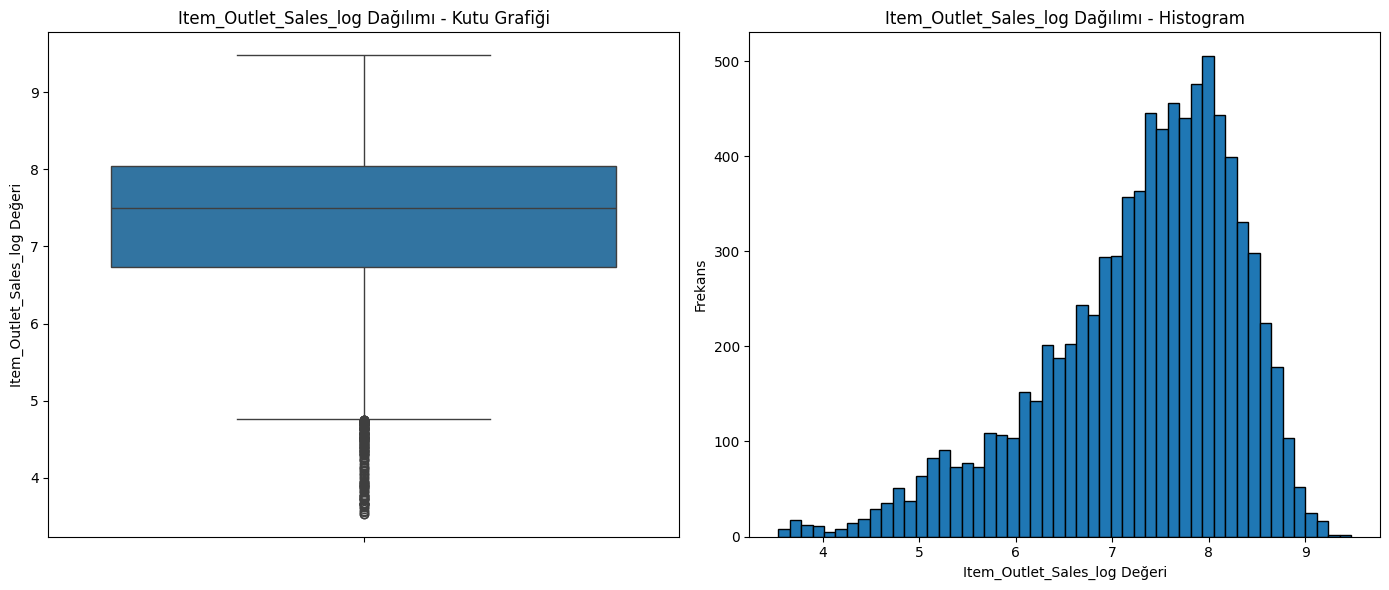

In [12]:
# 1. Grafik çerçevesinin boyutunu ayarlar (Genişlik: 14, Yükseklik: 6 birim).
plt.figure(figsize=(14, 6))

# --- SOLDAKİ GRAFİK: KUTU GRAFİĞİ ---
# 2. 1 satır ve 2 sütundan oluşan bir panel oluşturur ve 1. sıradaki grafiği seçer.
plt.subplot(1, 2, 1)

# 3. Logaritması alınmış satış verilerinin Kutu Grafiğini (Boxplot) çizer.
# Bu grafik, veride hala aykırı değer kalıp kalmadığını görmemizi sağlar.
sns.boxplot(y=df['Item_Outlet_Sales_log'])
plt.title('Item_Outlet_Sales_log Dağılımı - Kutu Grafiği')
plt.ylabel('Item_Outlet_Sales_log Değeri')

# --- SAĞDAKİ GRAFİK: HİSTOGRAM ---
# 4. Aynı panel içindeki 2. sıradaki (sağdaki) grafiği seçer.
plt.subplot(1, 2, 2)

# 5. Logaritmik verinin frekans dağılımını (Histogram) çizer.
# bins=50: Veriyi 50 adet çubuk (kutu) halinde gruplar.
plt.hist(df['Item_Outlet_Sales_log'], bins=50, edgecolor='black')
plt.title('Item_Outlet_Sales_log Dağılımı - Histogram')
plt.xlabel('Item_Outlet_Sales_log Değeri')
plt.ylabel('Frekans')

# 6. Grafiklerin birbirine girmesini engeller ve düzgünce yerleştirir.
plt.tight_layout()

# 7. Oluşturulan iki grafiği ekranda gösterir.
plt.show()

- Üstteki devasa aykırı değerleri logaritma ile "evcilleştirdiğimizde", verinin ölçeği küçüldüğü için alt tarafta bazı değerlerin dışarıda kalması sık rastlanan bir durumdur.

In [13]:
# Analiz edilecek kategorik sütunların listesi
categorical_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
                    'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

# 1. Kategorik sütunları döngü ile analiz etme (Adım 3.5 ve 3.6 mantığı)
for col in categorical_cols:
    print(f"\n--- {col} Dağılımı (Aykırı Değerler İçin) ---")
    # value_counts() ile hangi kategoriden kaç tane aykırı değer geldiğini hesaplar
    display(outliers[col].value_counts().head() if col == 'Item_Type' else outliers[col].value_counts())

# 2. Sayısal sütunların istatistiksel özeti (Adım 3.3: describe)
print("\n--- Aykırı Değerlerin Sayısal Özellikleri (İstatistik) ---")
# describe() ile ortalama, min, max gibi temel değerleri raporlar
display(outliers[['Item_Weight', 'Item_Visibility', 'Item_MRP',
                  'Outlet_Establishment_Year', 'Item_Outlet_Sales']].describe())


--- Item_Fat_Content Dağılımı (Aykırı Değerler İçin) ---


,count
Item_Fat_Content,
Low Fat,123
Regular,63



--- Item_Type Dağılımı (Aykırı Değerler İçin) ---


,count
Item_Type,
Fruits and Vegetables,33
Snack Foods,27
Dairy,21
Household,20
Frozen Foods,15



--- Outlet_Identifier Dağılımı (Aykırı Değerler İçin) ---


...

,count
Outlet_Location_Type,
Tier 3,121
Tier 2,44
Tier 1,21



--- Outlet_Type Dağılımı (Aykırı Değerler İçin) ---


,count
Outlet_Type,
Supermarket Type3,103
Supermarket Type1,80
Supermarket Type2,3



--- Aykırı Değerlerin Sayısal Özellikleri (İstatistik) ---


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,186.000000,186.000000,186.000000,186.000000,186.000000
mean,12.902782,0.056015,223.094063,1991.725806,7646.329986
std,2.945952,0.038117,31.588090,8.866279,1113.245443
min,5.695000,0.000000,125.933600,1985.000000,6503.534400
25%,12.857645,0.025791,193.057650,1985.000000,6853.079400
50%,12.857645,0.052674,229.999700,1985.000000,7256.887100
75%,12.857645,0.076565,249.531600,2001.250000,8101.953750
max,21.350000,0.175143,266.588400,2009.000000,13086.964800


### Aykırı Değerlerin Detaylı Analizi ve Gözlemler:

Aykırı değer olarak tespit edilen 186 gözlem üzerinde yapılan detaylı incelemeler, bu yüksek satışlı ürünlerin ve satış noktalarının belirli ortak özelliklere sahip olduğunu göstermektedir:

**1. Outlet Bilgileri:**
*   **Outlet_Identifier (OUT027):** Aykırı değerlerin büyük bir çoğunluğu (186 aykırı değerin 103'ü), `OUT027` tanımlayıcısına sahip satış noktasından gelmektedir. Bu durum, `OUT027`'nin istisnai derecede yüksek satış hacmine sahip olduğunu veya benzersiz özelliklere sahip olduğunu düşündürmektedir.
*   **Outlet_Type (Supermarket Type3):** `OUT027`'nin 'Supermarket Type3' tipinde bir satış noktası olması dikkat çekicidir. Aykırı değerlerin önemli bir kısmı (103 gözlem), bu süpermarket tipinden gelmektedir. 'Supermarket Type1' da 80 aykırı değer ile ikinci sırada yer almaktadır.
*   **Outlet_Size (Medium):** Aykırı değerlerin büyük çoğunluğu (%78'den fazlası), 'Medium' boyutundaki satış noktalarından gelmektedir (145 gözlem). Bu, orta büyüklükteki süpermarketlerin yüksek satış potansiyeline sahip olduğunu gösterebilir.
*   **Outlet_Location_Type (Tier 3):** Aykırı değerlerin çoğu ('Tier 3' konumunda bulunan 121 gözlem), daha uzak veya daha az popüler bölgelerde bulunan satış noktalarından gelmektedir. Bu durum, `OUT027`'nin 'Tier 3' lokasyonunda olmasına rağmen yüksek satışlar elde etmesinin özel bir durumu olabileceğini işaret eder.
*   **Outlet_Establishment_Year:** Aykırı değerlere sahip satış noktalarının kurulum yılları 1985 ile 2009 arasında değişmektedir. Özellikle 1985 yılında kurulan satış noktalarından (ki bu `OUT027`'ye denk gelmektedir) önemli sayıda aykırı değer gelmektedir.

**2. Ürün Bilgileri:**
*   **Item_MRP (Ürün Perakende Fiyatı):** Aykırı değerler arasında `Item_MRP` değeri ortalaması (223.09) oldukça yüksektir. Bu, yüksek satışa sahip ürünlerin genel olarak yüksek fiyatlı ürünler olduğunu göstermektedir. IQR aralığına göre, bu aykırı değerler için minimum MRP 125.93, maksimum MRP 266.58'dir. Bu da, ürünlerin genellikle pahalı segmentte olduğunu doğrular.
*   **Item_Fat_Content:** Aykırı değerler arasında 'Low Fat' ürünlerin ('Low Fat': 123) 'Regular' ürünlere ('Regular': 63) kıyasla daha fazla satış yaptığı görülmektedir.
*   **Item_Type:** 'Fruits and Vegetables' (33), 'Snack Foods' (27), 'Dairy' (21) ve 'Household' (20) gibi ürün kategorileri, aykırı değerler arasında en sık görülenlerdir. Bu kategorilerdeki ürünlerin yüksek satış potansiyeli taşıdığı söylenebilir.
*   **Item_Visibility:** Ortalama `Item_Visibility` (0.056) genel ortalamanın altındadır, bu da görünürlüğün her zaman yüksek satışın ana etkeni olmadığını düşündürebilir veya bu ürünlerin zaten çok talep gören ürünler olduğunu gösterebilir. Minimum `Item_Visibility`'nin 0.000 olması, bazı ürünlerin hiç görünürlük olmadan da yüksek satış yapabildiğini veya bu alanın yanlış girildiğini gösterebilir.

**3. Item_Weight:** Aykırı değerlerin `Item_Weight` ortalaması (12.90) genel ortalamaya (12.85) çok yakındır. Bu sütundaki eksik değerlerin ortalama ile doldurulmuş olması nedeniyle, bu gözlemin çok belirleyici olmadığını söyleyebiliriz.

**Olası Nedenler ve Hipotezler:**

*   **Outlet_Type (Supermarket Type3) Etkisi:** 'Supermarket Type3' olarak tanımlanan `OUT027` satış noktası, diğer satış noktalarına kıyasla farklı bir iş modeli, daha geniş bir müşteri tabanı veya özel promosyonlar gibi avantajlara sahip olabilir. Bu tip süpermarketler genellikle daha büyük ve daha çekici olabilir, bu da daha yüksek satışlara yol açar.
*   **Yüksek Fiyatlı Ürünlerin Popülaritesi:** Aykırı değerlerin çoğunun yüksek `Item_MRP` değerine sahip olması, tüketicilerin belirli yüksek fiyatlı ürünlere olan talebinin güçlü olduğunu gösteriyor. Bu ürünler, markalı ürünler, özel ürünler veya yüksek kaliteli ürünler olabilir.
*   **Ürün Kategorisi Özelindeki Talep:** 'Fruits and Vegetables', 'Snack Foods' ve 'Dairy' gibi temel gıda maddelerinin veya sık tüketilen ürünlerin yüksek satışlar yapması beklenebilir. Bu kategorilerdeki belirli ürünlerin popülaritesi aykırı değerlere katkıda bulunuyor olabilir.
*   **Pazarlama ve Promosyonlar:** Belirli satış noktalarında veya belirli ürünler için uygulanan etkili pazarlama stratejileri, kampanyalar veya promosyonlar, satışları beklenenin üzerine çıkararak aykırı değerlere neden olabilir.

Bu analiz, aykırı değerlerin rastgele olmadığını, belirli satış noktası ve ürün özellikleriyle ilişkili olduğunu göstermektedir. Özellikle `OUT027` satış noktasının ve 'Supermarket Type3' tipindeki satış noktalarının yüksek satışlarda önemli bir rol oynadığı açıktır.


## Kategorik Verilerin Kodlanması (Encoding): One-Hot Encoding

Makine öğrenimi modelleri genellikle sayısal verilerle çalıştığı için, metin tabanlı kategorik sütunları sayısal temsillerine dönüştürmemiz gerekir. Bu adımda, `Item_Fat_Content`, `Item_Type`, `Outlet_Identifier`, `Outlet_Size`, `Outlet_Location_Type` ve `Outlet_Type` gibi kategorik sütunlara One-Hot Encoding uygulayacağız. Bu yöntem, her kategorik değeri yeni ikili (0 veya 1) sütunlara dönüştürür.

In [14]:
# Kodlanacak kategorik sütunları tanımlayalım
categorical_cols_to_encode = ['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
                                'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

# One-Hot Encoding uygulayalım
# kategorical verileri dummies verilere çeviriyoruz.
# drop_first=True parametresi, çoklu doğrusal bağıntıyı (multicollinearity) önlemek için ilk kategorinin düşürülmesini sağlar.
df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

print("One-Hot Encoding sonrası DataFrame'in ilk 5 satırı ve sütun bilgileri:")
display(df_encoded.head())
print("\nDataFrame'in yeni sütun sayısı:", df_encoded.shape[1])

One-Hot Encoding sonrası DataFrame'in ilk 5 satırı ve sütun bilgileri:


,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Outlet_Sales_log,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,...,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,FDA15,9.30,0.016047,249.8092,1999,3735.1380,8.225808,False,False,False,...,False,False,True,True,False,False,False,True,False,False
1,DRC01,5.92,0.019278,48.2692,2009,443.4228,6.096776,True,False,False,...,False,False,False,True,False,False,True,False,True,False
2,FDN15,17.50,0.016760,141.6180,1999,2097.2700,7.648868,False,False,False,...,False,False,True,True,False,False,False,True,False,False
3,FDX07,19.20,0.000000,182.0950,1998,732.3800,6.597664,True,False,False,...,False,False,False,True,False,False,True,False,False,False
4,NCD19,8.93,0.000000,53.8614,1987,994.7052,6.903451,False,False,False,...,False,False,False,False,False,False,True,True,False,False



DataFrame'in yeni sütun sayısı: 39


In [15]:
df_encoded.info()
#encoded işleminden sonra yine bir veri seti bilgilerine bakıyoruz.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 39 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Item_Identifier                  8523 non-null   object 
 1   Item_Weight                      8523 non-null   float64
 2   Item_Visibility                  8523 non-null   float64
 3   Item_MRP                         8523 non-null   float64
 4   Outlet_Establishment_Year        8523 non-null   int64  
 5   Item_Outlet_Sales                8523 non-null   float64
 6   Item_Outlet_Sales_log            8523 non-null   float64
 7   Item_Fat_Content_Regular         8523 non-null   bool   
 8   Item_Type_Breads                 8523 non-null   bool   
 9   Item_Type_Breakfast              8523 non-null   bool   
 10  Item_Type_Canned                 8523 non-null   bool   
 11  Item_Type_Dairy                  8523 non-null   bool   
 12  Item_Type_Frozen Foo

In [16]:
# Giriş özelliklerini (X) ve hedef değişkeni (y) oluşturalım
X = df_encoded.drop(columns=["Item_Outlet_Sales", "Item_Outlet_Sales_log", "Item_Identifier"])
y = df_encoded["Item_Outlet_Sales_log"]

print("X (Girişler) DataFrame'inin ilk 5 satırı:")
display(X.head())

print("\ny (Hedef) Series'inin ilk 5 değeri:")
display(y.head())

X (Girişler) DataFrame'inin ilk 5 satırı:


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,...,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,1999,False,False,False,False,True,False,...,False,False,True,True,False,False,False,True,False,False
1,5.92,0.019278,48.2692,2009,True,False,False,False,False,False,...,False,False,False,True,False,False,True,False,True,False
2,17.50,0.016760,141.6180,1999,False,False,False,False,False,False,...,False,False,True,True,False,False,False,True,False,False
3,19.20,0.000000,182.0950,1998,True,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
4,8.93,0.000000,53.8614,1987,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False



y (Hedef) Series'inin ilk 5 değeri:


,Item_Outlet_Sales_log
0,8.225808
1,6.096776
2,7.648868
3,6.597664
4,6.903451


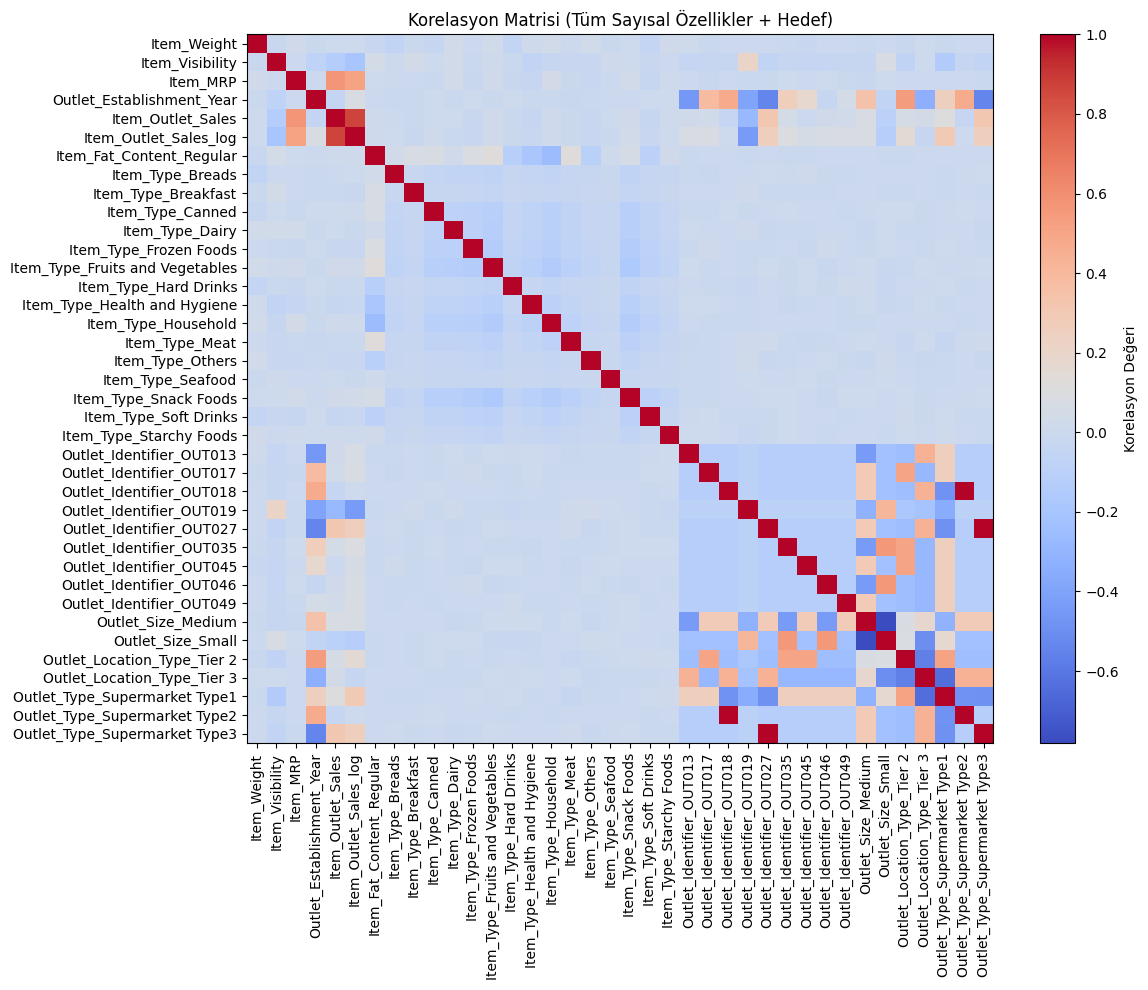

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# df_encoded DataFrame'indeki tüm sayısal sütunlar arasındaki korelasyonu hesapla
# Item_Identifier sütunu object tipinde olduğu için otomatik olarak dışarıda bırakılır veya manuel olarak düşürülebilir.
# Burada 'numeric_only=True' parametresi sadece sayısal sütunları dahil edecektir.
corr = df_encoded.corr(numeric_only=True)

plt.figure(figsize=(12,10)) # Korelasyon matrisinin daha iyi görünmesi için figür boyutunu büyüttük
plt.imshow(corr, aspect='auto', cmap='coolwarm') # Renk haritası (cmap) ekleyerek daha okunaklı hale getirdik
plt.colorbar(label='Korelasyon Değeri')
plt.title("Korelasyon Matrisi (Tüm Sayısal Özellikler + Hedef)")

# X ve Y eksen etiketlerini ayarla
plt.xticks(ticks=np.arange(len(corr.columns)), labels=corr.columns, rotation=90, fontsize=10)
plt.yticks(ticks=np.arange(len(corr.columns)), labels=corr.columns, fontsize=10)

plt.tight_layout() # Etiketlerin çakışmasını önlemek için düzeni ayarla
plt.show()

In [18]:
# 'Item_Outlet_Sales_log' sütunu ile diğer sütunların korelasyonlarını alalım
correlation_with_target = corr['Item_Outlet_Sales_log'].sort_values(ascending=False)

# Kendisiyle olan mükemmel korelasyonu (1.0) ve negatif korelasyonları hariç tutarak en yüksek pozitif korelasyonlara sahip sütunları listeleyelim
# İlk değer her zaman 'Item_Outlet_Sales_log'un kendisi olacağı için onu atlıyoruz.
print("Item_Outlet_Sales_log ile en yüksek pozitif korelasyona sahip sütunlar:")
display(correlation_with_target[1:])


Item_Outlet_Sales_log ile en yüksek pozitif korelasyona sahip sütunlar:


,Item_Outlet_Sales_log
Item_Outlet_Sales,0.861762
Item_MRP,0.509886
Outlet_Type_Supermarket Type1,0.286541
Outlet_Identifier_OUT027,0.251769
Outlet_Type_Supermarket Type3,0.251769
Outlet_Location_Type_Tier 2,0.149934
Outlet_Identifier_OUT035,0.094751
Outlet_Identifier_OUT049,0.080227
Outlet_Establishment_Year,0.077032
Outlet_Identifier_OUT017,0.075747


## Veri Setinin Eğitim, Doğrulama ve Test Olarak Bölünmesi

Makine öğrenimi modellerinin güvenilir bir şekilde eğitilmesi ve performansının değerlendirilmesi için veri setini üç ayrı parçaya ayırıyoruz:

*   **Eğitim (Train) Seti (%70):** Modelin öğrenme sürecinde kullanılacak ana veri setidir. Model bu veri üzerindeki desenleri öğrenir.
*   **Doğrulama (Validation) Seti (%15):** Modelin eğitim sırasında performansını izlemek ve hiperparametre ayarlarını optimize etmek için kullanılır. Modelin aşırı öğrenmesini (overfitting) engellemeye yardımcı olur.
*   **Test Seti (%15):** Modelin eğitim ve doğrulama süreçlerinde hiç görmediği, tamamen yeni verilerle gerçek dünya performansını ölçmek için kullanılır. Modelin genelleme yeteneğini gösterir.

Bu ayrımı `sklearn.model_selection` kütüphanesindeki `train_test_split` fonksiyonunu kullanarak iki aşamalı bir yaklaşımla gerçekleştireceğiz.

In [19]:
from sklearn.model_selection import train_test_split

# 1) Önce Train (%70) ve Geçici (%30) olarak ayır
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,  # %30'u geçici olarak ayır
    random_state=42
)

# 2) Geçici (%30) kısmı Validation (%15) ve Test (%15) olacak şekilde ikiye böl
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,  # %30'un %50'si = %15
    random_state=42 # Burada da aynı random_state'i kullanarak tutarlılık sağlıyoruz
)

print("Train set boyutları:", X_train.shape, y_train.shape)
print("Validation set boyutları:", X_val.shape, y_val.shape)
print("Test set boyutları:", X_test.shape, y_test.shape)

Train set boyutları: (5966, 36) (5966,)
Validation set boyutları: (1278, 36) (1278,)
Test set boyutları: (1279, 36) (1279,)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# 1) scaler sadece train verisinden öğrenir ve train verisini dönüştürür
X_train_scaled = scaler.fit_transform(X_train)

# 2) val ve test verileri, train verisinden öğrenilen scaler ile sadece dönüştürülür
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Ölçeklenmiş Train setinin boyutları:", X_train_scaled.shape)
print("Ölçeklenmiş Validation setinin boyutları:", X_val_scaled.shape)
print("Ölçeklenmiş Test setinin boyutları:", X_test_scaled.shape)

# Dönüştürülmüş verileri DataFrame olarak geri almak isterseniz:
# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
# X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
# X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

Ölçeklenmiş Train setinin boyutları: (5966, 36)
Ölçeklenmiş Validation setinin boyutları: (1278, 36)
Ölçeklenmiş Test setinin boyutları: (1279, 36)


- ölçeklendirilmiş değerlere bakıyoruz.

In [21]:
print("Train ölçekli ortalama (yaklaşık 0 olmalı):")
print(np.mean(X_train_scaled, axis=0))
print("\nTrain ölçekli std (yaklaşık 1 olmalı):")
print(np.std(X_train_scaled, axis=0))

Train ölçekli ortalama (yaklaşık 0 olmalı):
[ 1.10166281e-17 -3.98980584e-17  1.29817563e-16 -9.97927855e-15
  5.47853936e-17 -2.50107232e-17  3.09656573e-17  2.78393169e-17
  4.79372194e-17 -2.85836836e-17 -8.21780905e-17 -5.89538475e-17
 -4.85327128e-17 -9.52789455e-18  2.17355094e-17 -4.76394727e-18
  4.22800320e-17 -3.51341111e-17  4.76394727e-17 -2.64994567e-17
 -4.04935518e-17  2.85836836e-17 -2.50107232e-17  5.06169398e-17
  7.14592091e-18  2.85836836e-17 -3.81115782e-17  3.57296045e-17
  4.76394727e-18  2.38197364e-17 -7.26501959e-17 -4.76394727e-18
 -7.14592091e-18 -1.16716708e-16 -2.50107232e-17  7.14592091e-18]

Train ölçekli std (yaklaşık 1 olmalı):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


- MLP için kullanılan verilerin numpy dizisi şeklinde olması önemlidir.

In [22]:
# y değerlerini numpy dizisine çevirme
y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
y_test_np = y_test.to_numpy()

print("y_train_np shape:", y_train_np.shape)
print("y örnek değerler (y_train_np ilk 5 değeri):", y_train_np[:5])

y_train_np shape: (5966,)
y örnek değerler (y_train_np ilk 5 değeri): [4.77783359 7.11590571 8.50402244 7.49034535 8.26203216]


- MLP modelinin mimarisini tanımlayacak, hiperparametreleri ayarlayacak, eğitim döngüsünü çalıştıracak, erken durdurma mekanizmasını kullanacak, performans metriklerini hesaplayacak ve eğitim sürecini ile modelin tahmin performansını çeşitli grafiklerle görselleştireceğiz.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.8249 - val_loss: 0.3410
Epoch 2/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3507 - val_loss: 0.3226
Epoch 3/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3215 - val_loss: 0.3123
Epoch 4/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3051 - val_loss: 0.3083
Epoch 5/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2979 - val_loss: 0.3142
Epoch 6/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2933 - val_loss: 0.3105
Epoch 7/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2879 - val_loss: 0.3076
Epoch 8/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2837 - val_loss: 0.3059
Epoch 9/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2801 - val_loss: 0.3069
Epoch 10/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2772 - val_loss: 0.3089
Epoch 11/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2747 - val_loss: 0.3092
Epoch 12/300
187/187 ━━━━━━━━━━━━━━━

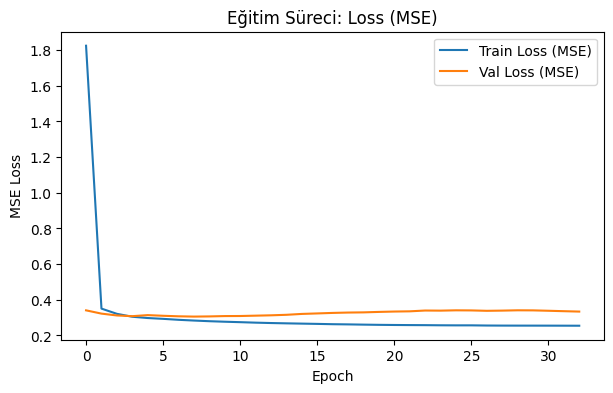

187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Split,R2,MSE,RMSE,MAE,MAPE(%)
0,Train,0.740477,0.264610,0.514403,0.399325,5.772298
1,Validation,0.696473,0.305936,0.553115,0.427849,6.242568
2,Test,0.716655,0.311889,0.558471,0.433810,6.372593



Metriklerin anlamı (regresyon): - R2: 1'e yaklaştıkça açıklanan varyans artar (1 mükemmel, 0: ortalama kadar, negatif: ortalamadan kötü). - MSE: Ortalama karesel hata. Büyük hataları daha çok cezalandırır (ölçek: hedefin karesi). - RMSE: MSE'nin karekökü. Hedef değişkenin birimiyle aynı ölçekte “tipik hata” gibi okunur. - MAE: Ortalama mutlak hata. Daha yorumlanabilir, uç değerlere MSE kadar hassas değildir. - MAPE(%): Yüzdesel hata. “Ortalama yüzde kaç yanıldım?” gibi okunur (y=0 yakınında dikkat).



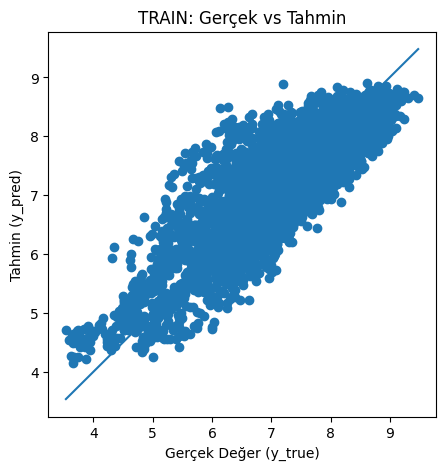

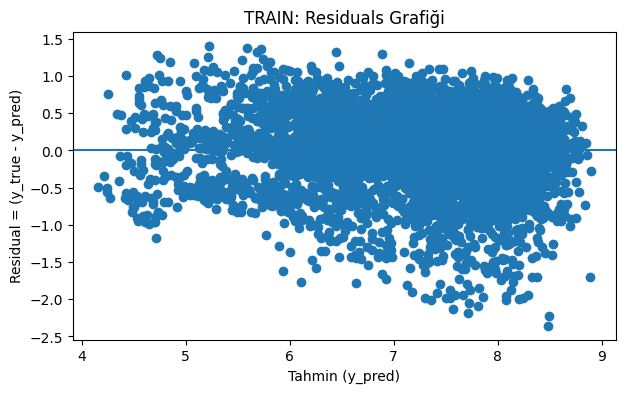

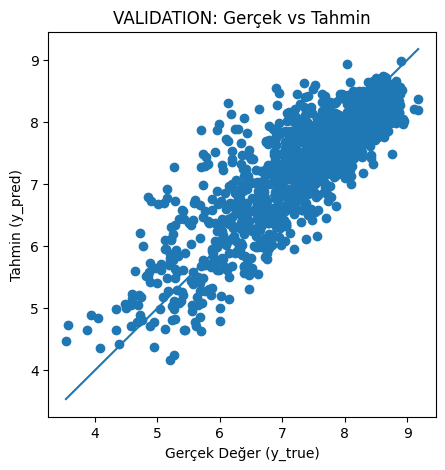

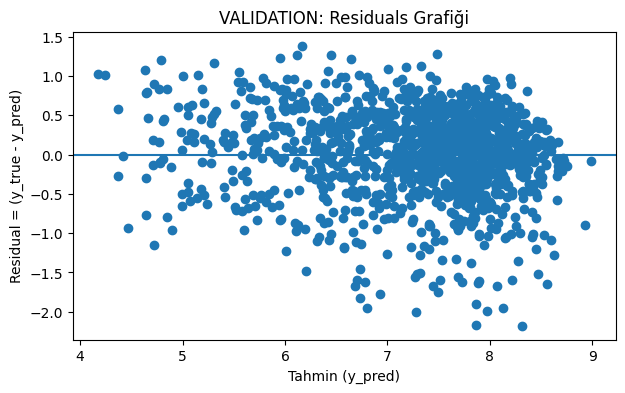

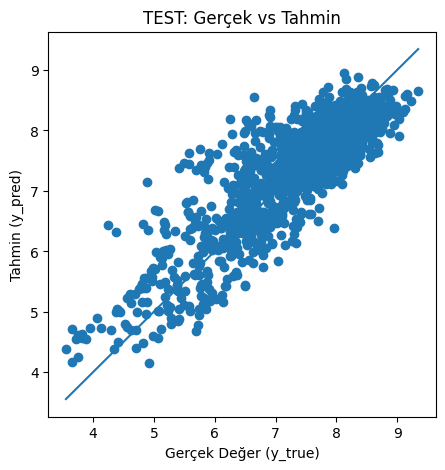

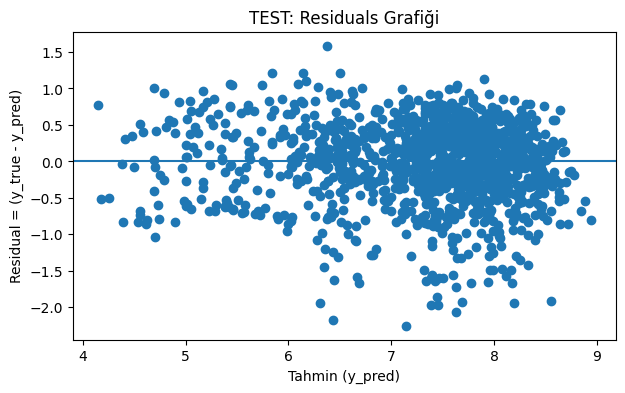

In [23]:
# =========================
# ADIM 5 - MLP REGRESYON
# =========================
# 1) Gerekli kütüphaneler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -------------------------
# 2) HİPERPARAMETRELER (ders amaçlı: değişkenlerden yönet)
# -------------------------
# Mimari
NUM_HIDDEN_LAYERS = 2            # kaç gizli katman var bakıyoruz.
NEURONS_PER_LAYER = [64, 32]     # her gizli katmandaki nöron sayısı (NUM_HIDDEN_LAYERS ile uyumlu olmalı)
HIDDEN_ACTIVATION = "relu"       # gizli katman aktivasyonu
#ReLU'nun mantığı oldukça basittir: Eğer gelen değer negatifse onu sıfıra eşitle; pozitifse olduğu gibi bırak.

# Optimizasyon
LEARNING_RATE = 0.01             # öğrenme oranı
MOMENTUM = 0.9                   # momentum (SGD için)
OPTIMIZER_NAME = "sgd"           # "sgd" veya "adam" seçebilirsin (aşağıda if ile yönetiliyor)
#OPTIMIZER_NAME = "sgd" ifadesi, yapay zekanın öğrenme stratejisini belirleyen bir ayardır.
#sgd ->Verinin tamamını beklemediği için her adımda hızlıca güncellenir.


# Eğitim döngüsü
EPOCHS = 300   #Modelin, elindeki tüm verileri toplamda 300 kez göreceğini gösterir.
BATCH_SIZE = 32  #Eğitim setindeki verilerin 32'şerli gruplar halinde modele verilmesidir
#Tüm veriyi aynı anda işlemek bilgisayarını kilitleyebilir. 32, hem hız hem de bellek kullanımı açısından "altın orta" kabul edilen standart bir değerdir.

# Erken durdurma (durdurma fonksiyonu)
#bu ayarlar sayesinde modelin boş yere çalışmasını veya veriyi ezberleyip (overfitting) performansının düşmesini engellersiniz.
USE_EARLY_STOPPING = True        # 300 epoch belirlemiş olabilirsin, ancak model 80. epoch'ta zaten en iyi seviyesine ulaşmış olabilir. Devam etmek hem zaman kaybıdır hem de modelin eğitim verisine aşırı odaklanıp hata yapmasına sebep olur
EARLY_STOP_PATIENCE = 25         # Modelin performansında bir iyileşme durduğunda, ona verdiğin "son şans" süresidir.
#Diyelim ki 100. epoch'ta en düşük hata payına ulaştın. 101'den itibaren 25 epoch boyunca (yani 125. epoch'a kadar) bu rekor kırılamazsa, sistem "Tamam, artık daha iyiye gitmeyecek" der ve eğitimi durdurur.
RESTORE_BEST_WEIGHTS = True      # en iyi validation ağırlıklarını geri yükle
#Eğitim bittiğinde, modelin elindeki "en son" (kötüleşmiş) halini değil, performansın zirve yaptığı (en iyi hata payının alındığı) andaki halini (ağırlıklarını) geri yükler.

# Tekrarlanabilirlik (aynı sonuçlara yakın üretmek için)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -------------------------
# 3) Girdi boyutu kontrolü
# -------------------------
input_dim = X_train_scaled.shape[1]
# Mevcut feature sayısı 36'dır, bu yüzden assertion'ı buna uygun veriyoruz.
assert input_dim == 36, f"Beklenen feature sayısı 36, ama {input_dim} geldi."

# -------------------------
# 4) MLP MODELİ OLUŞTURMA (Architecture)
# -------------------------
def build_mlp_regressor(input_dim: int):
    model = keras.Sequential()
    # Input + 1. gizli katman
    model.add(layers.Input(shape=(input_dim,)))
    model.add(layers.Dense(NEURONS_PER_LAYER[0], activation=HIDDEN_ACTIVATION))
    # Ek gizli katmanlar
    for i in range(1, NUM_HIDDEN_LAYERS):
        model.add(layers.Dense(NEURONS_PER_LAYER[i], activation=HIDDEN_ACTIVATION))
    # Çıkış katmanı: 1 nöron, lineer aktivasyon (regresyon)
    model.add(layers.Dense(1, activation="linear"))
    return model

model = build_mlp_regressor(input_dim)

# -------------------------
# 5) OPTIMIZER SEÇİMİ (öğrenme parametreleri)
# -------------------------
if OPTIMIZER_NAME.lower() == "sgd":
    optimizer = keras.optimizers.SGD(learning_rate=LEARNING_RATE, momentum=MOMENTUM)
elif OPTIMIZER_NAME.lower() == "adam":
    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
else:
    raise ValueError("OPTIMIZER_NAME sadece 'sgd' veya 'adam' olmalı.")

# Loss: MSE (regresyonda yaygın)
model.compile(
    optimizer=optimizer,
    loss="mse"
)
print(model.summary())

# -------------------------
# 6) CALLBACK: EARLY STOPPING
# -------------------------
callbacks = []
if USE_EARLY_STOPPING:
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=RESTORE_BEST_WEIGHTS
    )
    callbacks.append(early_stop)

# -------------------------
# 7) MODELİ EĞİTME (Training Loop)
# -------------------------
history = model.fit(
    X_train_scaled, y_train_np,
    validation_data=(X_val_scaled, y_val_np),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

# -------------------------
# 8) EĞİTİM EĞRİSİ (loss)
# -------------------------
plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="Train Loss (MSE)")
plt.plot(history.history["val_loss"], label="Val Loss (MSE)")
plt.title("Eğitim Süreci: Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# -------------------------
# 9) TAHMİN + METRİK HESAPLARI
# -------------------------
def compute_metrics(y_true, y_pred):
    # y_pred modelden (n,1) gelebilir, düzleştiriyoruz
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    # MAPE: |(y - yhat)/y| *100; y=0 riskine karşı küçük epsilon
    eps = 1e-8
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100
    r2 = r2_score(y_true, y_pred)
    return {"R2": r2, "MSE": mse, "RMSE": rmse, "MAE": mae, "MAPE(%)": mape}

# Train / Val / Test tahminleri
y_pred_train = model.predict(X_train_scaled).reshape(-1)
y_pred_val   = model.predict(X_val_scaled).reshape(-1)
y_pred_test  = model.predict(X_test_scaled).reshape(-1)

metrics_train = compute_metrics(y_train_np, y_pred_train)
metrics_val   = compute_metrics(y_val_np, y_pred_val)
metrics_test  = compute_metrics(y_test_np, y_pred_test)

# Tablo oluştur
metrics_df = pd.DataFrame([
    {"Split": "Train", **metrics_train},
    {"Split": "Validation", **metrics_val},
    {"Split": "Test", **metrics_test},
])
display(metrics_df)

# -------------------------
# 10) METRİKLERİN ANLAMI (ders notu için kısa, net)
# -------------------------
print("""
Metriklerin anlamı (regresyon): - R2: 1'e yaklaştıkça açıklanan varyans artar (1 mükemmel, 0: ortalama kadar, negatif: ortalamadan kötü). - MSE: Ortalama karesel hata. Büyük hataları daha çok cezalandırır (ölçek: hedefin karesi). - RMSE: MSE'nin karekökü. Hedef değişkenin birimiyle aynı ölçekte “tipik hata” gibi okunur. - MAE: Ortalama mutlak hata. Daha yorumlanabilir, uç değerlere MSE kadar hassas değildir. - MAPE(%): Yüzdesel hata. “Ortalama yüzde kaç yanıldım?” gibi okunur (y=0 yakınında dikkat).
""")

# -------------------------
# 11) GRAFİKLER: Gerçek vs Tahmin + Residuals (Train/Val/Test)
# -------------------------
def plot_true_vs_pred(y_true, y_pred, title):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred)
    # y=x referans çizgisi
    min_v = min(y_true.min(), y_pred.min())
    max_v = max(y_true.max(), y_pred.max())
    plt.plot([min_v, max_v], [min_v, max_v])
    plt.title(title)
    plt.xlabel("Gerçek Değer (y_true)")
    plt.ylabel("Tahmin (y_pred)")
    plt.show()

def plot_residuals(y_true, y_pred, title):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    residuals = y_true - y_pred
    plt.figure(figsize=(7,4))
    plt.scatter(y_pred, residuals)
    plt.axhline(0)
    plt.title(title)
    plt.xlabel("Tahmin (y_pred)")
    plt.ylabel("Residual = (y_true - y_pred)")
    plt.show()

# Train
plot_true_vs_pred(y_train_np, y_pred_train, "TRAIN: Gerçek vs Tahmin")
plot_residuals(y_train_np, y_pred_train, "TRAIN: Residuals Grafiği")

# Validation
plot_true_vs_pred(y_val_np, y_pred_val, "VALIDATION: Gerçek vs Tahmin")
plot_residuals(y_val_np, y_pred_val, "VALIDATION: Residuals Grafiği")

# Test
plot_true_vs_pred(y_test_np, y_pred_test, "TEST: Gerçek vs Tahmin")
plot_residuals(y_test_np, y_pred_test, "TEST: Residuals Grafiği")

MLP Model Eğitimi ve Hiperparametre Deneyleri (Grid-lite)

- Bu bölümde, Çok Katmanlı Algılayıcı (MLP) modelinin performansını optimize etmek için farklı hiperparametre kombinasyonlarını deneyeceğiz. Deneyler, farklı gizli katman yapıları, öğrenme oranları, batch boyutları, dropout ve L2 regülarizasyonunu içerecektir. Her deney sonucunda model eğitilecek, metrikler hesaplanacak ve `val_R2` değerine göre en iyi model seçilerek detaylı analiz ve görselleştirmeler yapılacaktır.

## MLP Model Eğitimi ve Hiperparametre Deneyleri

### Subtask:
Farklı gizli katman yapıları, öğrenme oranları, batch boyutları, dropout ve L2 regülarizasyonu gibi hiperparametre kombinasyonlarını kullanarak birden fazla MLP modeli eğitin. Her model için performans metriklerini (R2, MSE, RMSE, MAE, MAPE) hesaplayın.


In [24]:
experiments = [
    {'name': 'A_baseline_32-16', 'hidden': [32, 16], 'lr': 0.001, 'batch': 16, 'dropout': 0.0, 'l2': 0.0},
    {'name': 'B_small_16-8', 'hidden': [16, 8], 'lr': 0.001, 'batch': 16, 'dropout': 0.0, 'l2': 0.0},
    {'name': 'C_big_64-32', 'hidden': [64, 32], 'lr': 0.001, 'batch': 16, 'dropout': 0.0, 'l2': 0.0},
    {'name': 'D_lr_3e-4_32-16', 'hidden': [32, 16], 'lr': 0.0003, 'batch': 16, 'dropout': 0.0, 'l2': 0.0},
    {'name': 'E_batch_32_32-16', 'hidden': [32, 16], 'lr': 0.001, 'batch': 32, 'dropout': 0.0, 'l2': 0.0},
    {'name': 'F_dropout_0.1_32-16', 'hidden': [32, 16], 'lr': 0.001, 'batch': 16, 'dropout': 0.1, 'l2': 0.0},
    {'name': 'G_l2_0.001_32-16', 'hidden': [32, 16], 'lr': 0.001, 'batch': 16, 'dropout': 0.0, 'l2': 0.001}
]
results = []
trained_models = {}

# input_dim zaten tanımlı olmalı, önceki adımlarda X_train_scaled'den alınmış olmalı
# Eğer tanımlı değilse, bu kısmı eklemelisin: input_dim = X_train_scaled.shape[1]

for exp in experiments:
    print(f"\n--- Running Experiment: {exp['name']} ---")

    # Model Oluşturma
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for i, neurons in enumerate(exp['hidden']):
        # Gizli katman
        if exp['l2'] > 0:
            model.add(layers.Dense(neurons, activation='relu',
                                   kernel_regularizer=keras.regularizers.l2(exp['l2'])))
        else:
            model.add(layers.Dense(neurons, activation='relu'))

        # Dropout katmanı
        if exp['dropout'] > 0:
            model.add(layers.Dropout(exp['dropout']))

    # Çıkış katmanı
    model.add(layers.Dense(1, activation="linear"))

    # Modeli Derleme
    optimizer = keras.optimizers.Adam(learning_rate=exp['lr'])
    model.compile(
        optimizer=optimizer,
        loss="mse"
    )

    # Erken Durdurma Callback'i
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=25, # Sabit patience değeri kullanıldı
        restore_best_weights=True
    )
    callbacks_list = [early_stop]

    # Modeli Eğitme
    history = model.fit(
        X_train_scaled, y_train_np,
        validation_data=(X_val_scaled, y_val_np),
        epochs=800, # Sabit yüksek epoch değeri kullanıldı, erken durdurma ile yönetilecek
        batch_size=exp['batch'],
        callbacks=callbacks_list,
        verbose=0 # Her epoch'u yazdırmamak için 0 yapıldı, isteğe göre 1 yapılabilir
    )

    # Eğitilen modeli ve history'sini kaydet
    trained_models[exp['name']] = (model, history)

    # Tahminler
    y_pred_train = model.predict(X_train_scaled).reshape(-1)
    y_pred_val   = model.predict(X_val_scaled).reshape(-1)
    y_pred_test  = model.predict(X_test_scaled).reshape(-1)

    # Metrik Hesaplamaları
    metrics_train = compute_metrics(y_train_np, y_pred_train)
    metrics_val   = compute_metrics(y_val_np, y_pred_val)
    metrics_test  = compute_metrics(y_test_np, y_pred_test)

    # En iyi validation loss'u ve kullanılan epoch sayısını bul
    best_val_loss_epoch = np.argmin(history.history['val_loss'])
    best_val_loss = history.history['val_loss'][best_val_loss_epoch]
    epochs_used = best_val_loss_epoch + 1 # epoch index'i 0'dan başladığı için +1

    # Sonuçları kaydet
    results.append({
        'Experiment': exp['name'],
        'Hidden': str(exp['hidden']),
        'LR': exp['lr'],
        'Batch': exp['batch'],
        'Dropout': exp['dropout'],
        'L2': exp['l2'],
        'EpochsUsed': epochs_used,
        'BestValLoss(MSE)': best_val_loss,
        'Train_R2': metrics_train['R2'], 'Val_R2': metrics_val['R2'], 'Test_R2': metrics_test['R2'],
        'Train_RMSE': metrics_train['RMSE'], 'Val_RMSE': metrics_val['RMSE'], 'Test_RMSE': metrics_test['RMSE'],
        'Train_MAE': metrics_train['MAE'], 'Val_MAE': metrics_val['MAE'], 'Test_MAE': metrics_test['MAE'],
        'Train_MAPE(%)': metrics_train['MAPE(%)'], 'Val_MAPE(%)': metrics_val['MAPE(%)'], 'Test_MAPE(%)': metrics_test['MAPE(%)']
    })

# Sonuçları DataFrame olarak göster
results_df = pd.DataFrame(results)
print("\n--- Hyperparameter Experiment Results ---")
display(results_df.sort_values(by='Val_R2', ascending=False))


--- Running Experiment: A_baseline_32-16 ---
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

--- Running Experiment: B_small_16-8 ---
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

--- Running Experiment: C_big_64-32 ---
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

--- Running Experiment: D_lr_3e-4_32-16 ---
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

--- Running Experiment: E_batch_32_32-16 ---
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- Running Experiment: F_dropout_0.1_32-16 ---
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

--- Run

,Experiment,Hidden,LR,Batch,Dropout,L2,EpochsUsed,BestValLoss(MSE),Train_R2,Val_R2,Test_R2,Train_RMSE,Val_RMSE,Test_RMSE,Train_MAE,Val_MAE,Test_MAE,Train_MAPE(%),Val_MAPE(%),Test_MAPE(%)
5,F_dropout_0.1_32-16,"[32, 16]",0.0010,16,0.1,0.000,53,0.278812,0.745207,0.723383,0.733696,0.509693,0.528026,0.541416,0.396350,0.408805,0.418576,5.747944,5.964115,6.191737
1,B_small_16-8,"[16, 8]",0.0010,16,0.0,0.000,97,0.290790,0.743946,0.711499,0.717348,0.510953,0.539250,0.557787,0.393915,0.414831,0.431811,5.714521,6.056599,6.360637
3,D_lr_3e-4_32-16,"[32, 16]",0.0003,16,0.0,0.000,39,0.293425,0.747678,0.708885,0.724704,0.507216,0.541687,0.550481,0.397423,0.424197,0.430870,5.710575,6.137517,6.307433
0,A_baseline_32-16,"[32, 16]",0.0010,16,0.0,0.000,29,0.294373,0.743895,0.707945,0.713190,0.511004,0.542561,0.561875,0.392174,0.414507,0.432729,5.705135,6.065682,6.395106
6,G_l2_0.001_32-16,"[32, 16]",0.0010,16,0.0,0.001,164,0.323717,0.760874,0.699392,0.702450,0.493775,0.550448,0.572298,0.378578,0.420144,0.438826,5.497615,6.163738,6.482579
4,E_batch_32_32-16,"[32, 16]",0.0010,32,0.0,0.000,50,0.303360,0.750454,0.699028,0.708898,0.504418,0.550782,0.566064,0.395319,0.430662,0.443352,5.672135,6.241325,6.477347
2,C_big_64-32,"[64, 32]",0.0010,16,0.0,0.000,15,0.310445,0.737080,0.691999,0.711650,0.517759,0.557176,0.563382,0.411411,0.438770,0.443563,5.880930,6.338380,6.446789


## En İyi Modeli Seçme ve Değerlendirme

- Eğitilen modeller arasından `val_R2` değerine göre en iyi performans gösteren modeli seçin. Seçilen modelin eğitim eğrilerini (loss), gerçek vs. tahmin grafiklerini ve residual grafiklerini görselleştirerek performansını detaylı olarak değerlendirin.


In [25]:
best_experiment_row = results_df.loc[results_df['Val_R2'].idxmax()]
best_model_name = best_experiment_row['Experiment']
best_val_r2 = best_experiment_row['Val_R2']

print(f"En iyi model (Val_R2'ye göre): {best_model_name} (Val_R2: {best_val_r2:.4f})")

best_model, best_history = trained_models[best_model_name]

print("\nSeçilen modelin özeti:")
best_model.summary()

En iyi model (Val_R2'ye göre): F_dropout_0.1_32-16 (Val_R2: 0.7234)

Seçilen modelin özeti:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 32)             │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,189 (20.27 KB)

 Trainable params: 1,729 (6.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,460 (13.52 KB)

- en iyi modelle tahmin yapıp görselleştirdik.

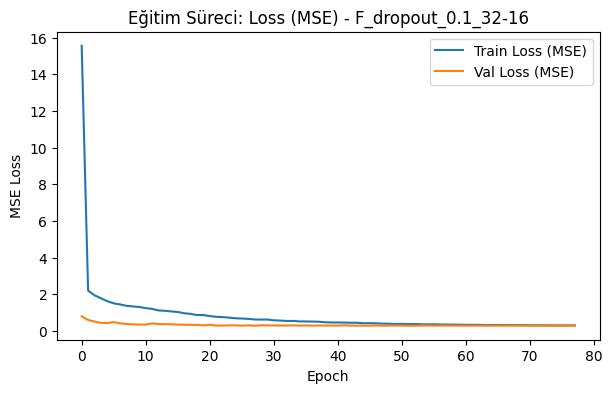

187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


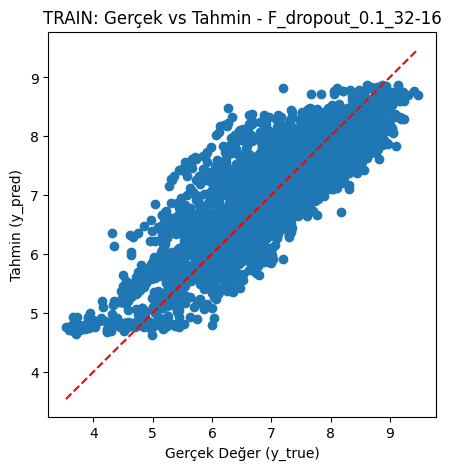

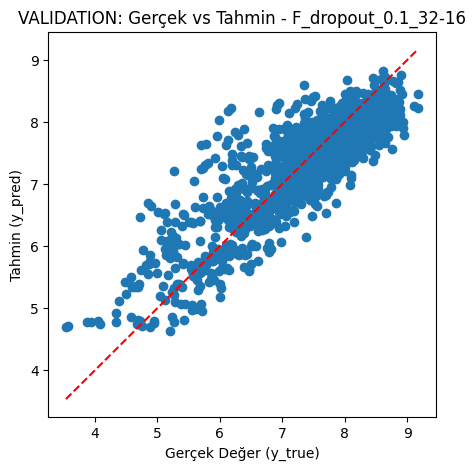

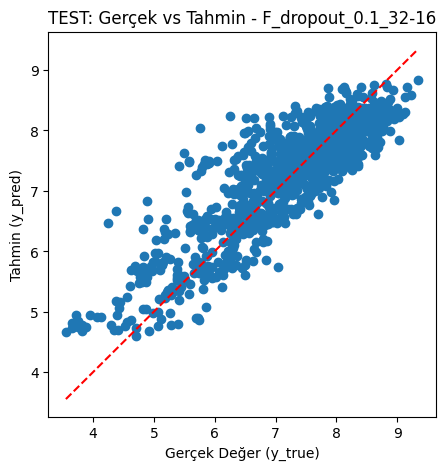

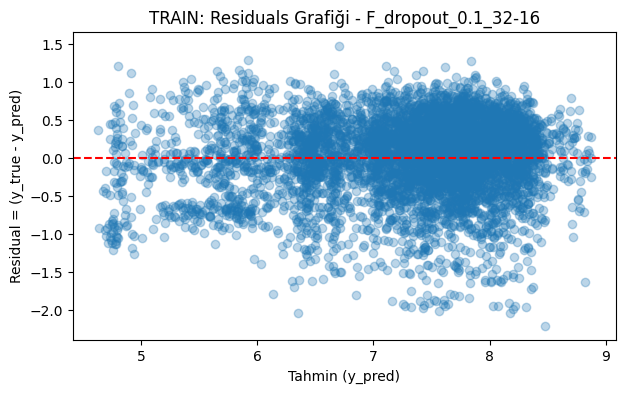

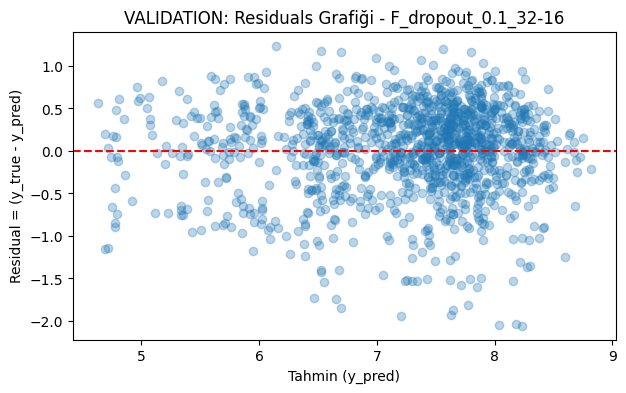

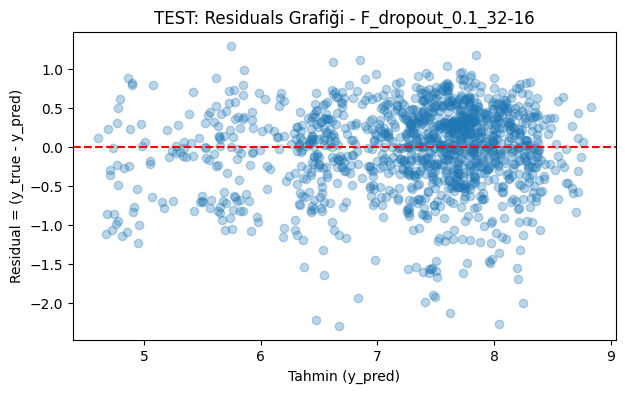

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 3. Eğitim ve Doğrulama Kaybını Gösteren Grafik
plt.figure(figsize=(7, 4))
plt.plot(best_history.history["loss"], label="Train Loss (MSE)")
plt.plot(best_history.history["val_loss"], label="Val Loss (MSE)")
plt.title(f"Eğitim Süreci: Loss (MSE) - {best_model_name}")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# 4. En İyi Model ile Tahminler Yapma
y_pred_train_best = best_model.predict(X_train_scaled).reshape(-1)
y_pred_val_best   = best_model.predict(X_val_scaled).reshape(-1)
y_pred_test_best  = best_model.predict(X_test_scaled).reshape(-1)

# Fonksiyonlar daha önce tanımlanmış olmalı: plot_true_vs_pred ve plot_residuals
# Eğer tanımlı değillerse, önceki hücreden kopyalanmaları gerekir.
# (Burada tanımlı oldukları varsayılmaktadır)

def plot_true_vs_pred(y_true, y_pred, title):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred)
    # y=x referans çizgisi
    min_v = min(y_true.min(), y_pred.min())
    max_v = max(y_true.max(), y_pred.max())
    plt.plot([min_v, max_v], [min_v, max_v], color='red', linestyle='--')
    plt.title(title)
    plt.xlabel("Gerçek Değer (y_true)")
    plt.ylabel("Tahmin (y_pred)")
    plt.show()

def plot_residuals(y_true, y_pred, title):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    residuals = y_true - y_pred
    plt.figure(figsize=(7,4))
    plt.scatter(y_pred, residuals, alpha=0.3)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(title)
    plt.xlabel("Tahmin (y_pred)")
    plt.ylabel("Residual = (y_true - y_pred)")
    plt.show()

# 5. Gerçek vs Tahmin Grafikleri
plot_true_vs_pred(y_train_np, y_pred_train_best, f"TRAIN: Gerçek vs Tahmin - {best_model_name}")
plot_true_vs_pred(y_val_np, y_pred_val_best, f"VALIDATION: Gerçek vs Tahmin - {best_model_name}")
plot_true_vs_pred(y_test_np, y_pred_test_best, f"TEST: Gerçek vs Tahmin - {best_model_name}")

# 6. Residual Grafikleri
plot_residuals(y_train_np, y_pred_train_best, f"TRAIN: Residuals Grafiği - {best_model_name}")
plot_residuals(y_val_np, y_pred_val_best, f"VALIDATION: Residuals Grafiği - {best_model_name}")
plot_residuals(y_test_np, y_pred_test_best, f"TEST: Residuals Grafiği - {best_model_name}")